# Data Visualization: Beyond Matplotlib
**Data Sciences Institute — Class follow-along notebook**

This notebook replicates the live code from the *Beyond Matplotlib* session and completes the in-class activities. Sections: Seaborn, Plotly, Wordclouds, and Venn diagrams.

## Setup: install and import packages

Run the install cell once if these packages aren't already in your environment.

In [ ]:
# Run once if needed (uncomment):
# !pip install seaborn plotly wordcloud matplotlib-venn

In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

# --- macOS fix for SSL certificate errors when downloading datasets ---
# python.org installs don't link to the system cert store, so HTTPS
# downloads (sns.load_dataset, the wordcloud CSV) fail to verify.
# Best fix: run /Applications/Python\ 3.11/Install\ Certificates.command
# in Terminal once. This in-notebook fallback patches it for the session:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

## Seaborn

Seaborn is built on top of matplotlib. It's very similar, but handles some of the **semantic mapping** for us — deciding which aspects of the dataset correspond to which visual elements.

### Load data — the `tips` sample dataset

In [2]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


The `tips` dataset contains information about tips at a restaurant: meal time, party size, gender of customer, total bill amount, and tip amount.

### Basic line plot — tip amount vs. total bill

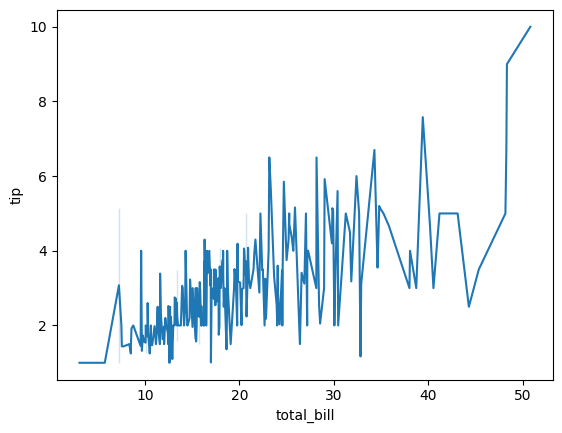

In [3]:
sns.lineplot(data=tips,   # choose our dataset
             x='total_bill',  # define our x variable
             y='tip')         # define our y variable
plt.show()

### Use premade styles

Try the preset styles: `'darkgrid'`, `'whitegrid'`, `'dark'`, `'white'`, `'ticks'`, then re-make the plot to see how it changes.

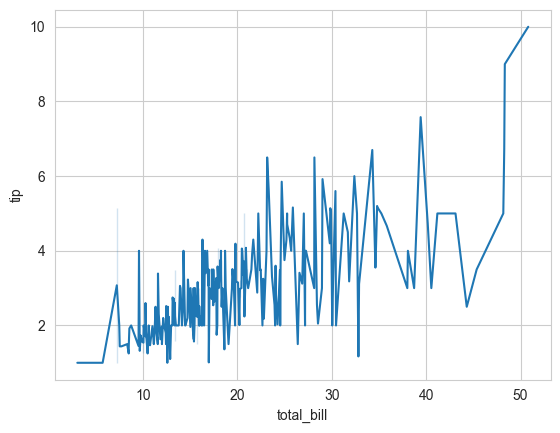

In [4]:
sns.set_style('whitegrid')

sns.lineplot(data=tips, x='total_bill', y='tip')
plt.show()

### Add title and axis labels (using the `.set()` method)

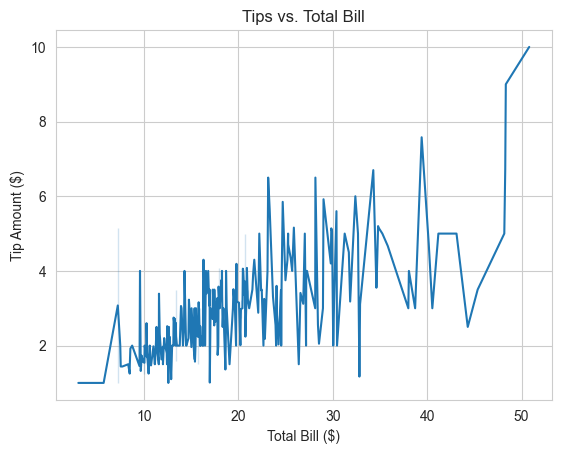

In [5]:
tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip')

tipgraph.set(title='Tips vs. Total Bill',
             xlabel='Total Bill ($)',
             ylabel='Tip Amount ($)')
plt.show()

### Modify aesthetic elements — figure size

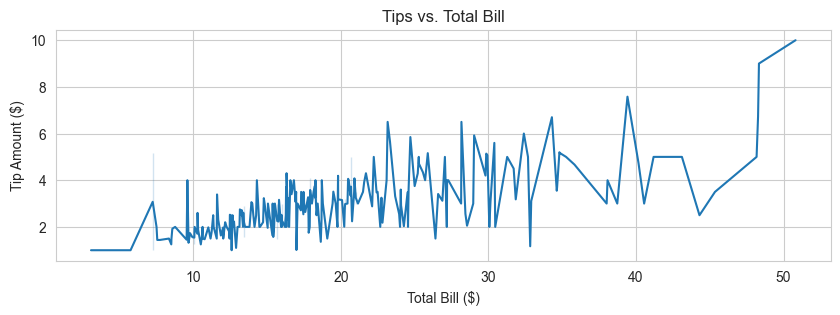

In [6]:
# Like in base matplotlib, use subplots to change figure size
fig = plt.subplots(figsize=(10, 3))

tipgraph = sns.lineplot(data=tips, x='total_bill', y='tip')
tipgraph.set(title='Tips vs. Total Bill',
             xlabel='Total Bill ($)',
             ylabel='Tip Amount ($)')
plt.show()

### Modify aesthetic elements — colour, marker, and line style

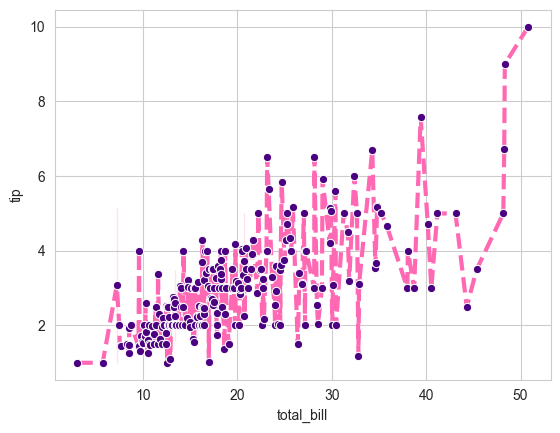

In [7]:
tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip',
                        color='hotpink',
                        linestyle='--',
                        linewidth=3,
                        marker='o',
                        markerfacecolor='indigo')
plt.show()

### Why is seaborn actually an improvement? Adding multiple variables

Seaborn makes it easy to represent multiple variables with different visual elements — here `style` maps to meal time and `hue` maps to day.

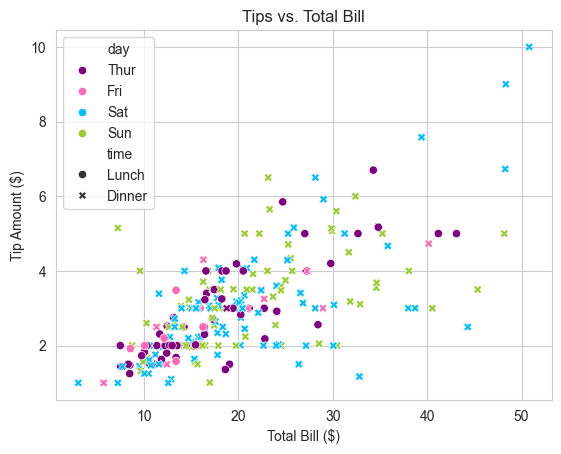

In [8]:
tipgraph = sns.scatterplot(data=tips,
                           x='total_bill',
                           y='tip',
                           style='time',
                           hue='day',
                           palette=['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])

tipgraph.set(title='Tips vs. Total Bill',
             xlabel='Total Bill ($)',
             ylabel='Tip Amount ($)')
plt.show()

### Pairplot — compare all variables at once

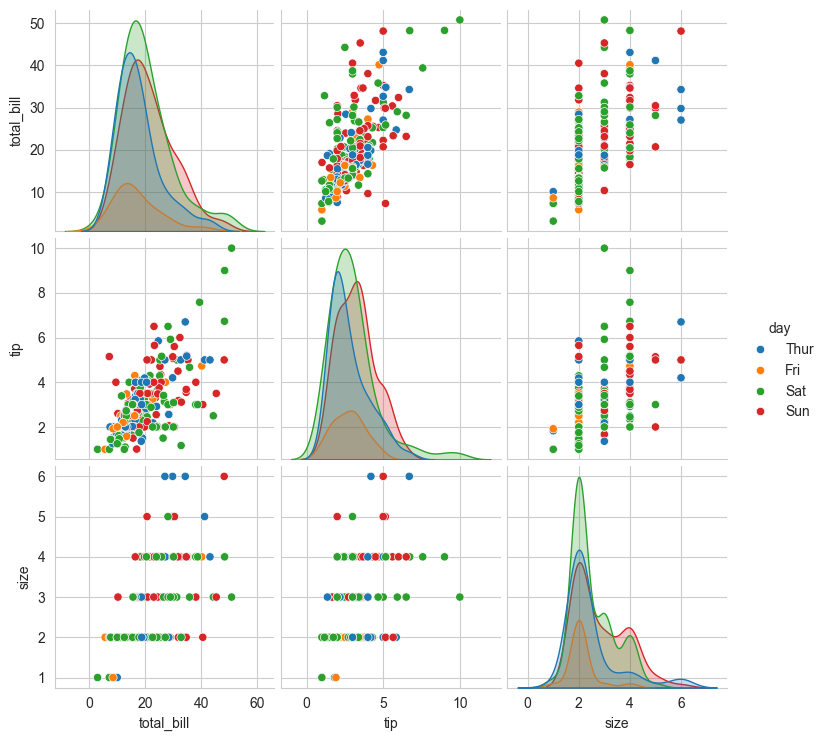

In [9]:
sns.pairplot(data=tips,
             hue='day')
plt.show()

### Relplot — explore specific levels within variables

**Activity (Slide 17):** Comment this snippet and describe what each new element is doing. (See the commented code below.)

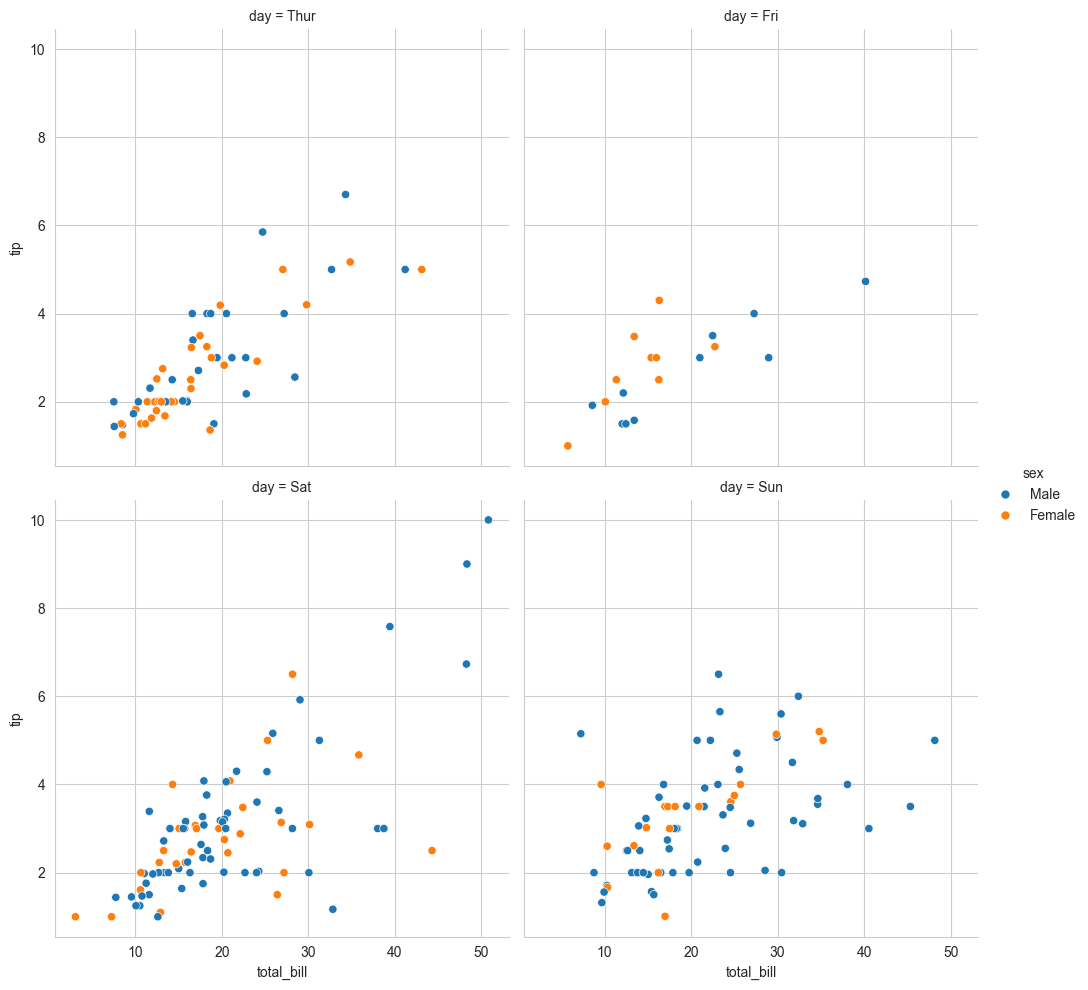

In [10]:
daysplot = sns.relplot(
    data=tips,          # the dataset to plot
    x="total_bill",     # x-axis variable
    y="tip",            # y-axis variable
    hue="sex",          # colour points by customer sex (Male/Female)
    col="day",          # create a SEPARATE subplot (facet) for each day
    kind="scatter",     # draw a scatter plot in each facet
    col_wrap=2)         # wrap the columns so there are 2 facets per row
plt.show()

**Activity answer — what each new element does:**

- `hue="sex"` — maps the *retinal* element of **colour** to the `sex` variable, so Male vs. Female points are coloured differently within each plot.
- `col="day"` — **facets** the data: instead of one plot, seaborn creates a separate subplot (a small multiple) for each level of `day` (Thur, Fri, Sat, Sun). This lets us compare the same relationship across days side by side.
- `kind="scatter"` — tells `relplot` which kind of relational plot to draw in each facet (scatter, as opposed to `"line"`).
- `col_wrap=2` — controls the *spatial* layout of the facets: after 2 columns, wrap to a new row. With 4 days, this produces a tidy 2×2 grid instead of a single row of 4.

`relplot` is a **figure-level** function: it manages the whole grid of facets and a shared legend, which is why it returns a `FacetGrid` rather than a single Axes.

## Case Study: Gender bias in teaching evaluations

**Activity (Slide 23): Comparing two visualizations.** No code — discussion. (See analysis below.)

**MacNell et al. (2015) bar chart** (mean student ratings by actual vs. perceived instructor gender):
- *What it does:* A static bar chart presenting four summary means with error bars. It makes a single, focused argument — perceived-female instructors are rated lower than perceived-male instructors even when the *actual* instructor is held constant.
- *Pros:* Clear, immediate, one unambiguous takeaway; error bars convey uncertainty; works in any medium (print, slide, mobile).
- *Cons:* Aggregated to four means, so it hides the underlying distribution and individual variation; you can't explore beyond what the designer chose to show; only one comparison.

**Schmidt (2015) interactive RateMyProfessor chart** (gendered language across disciplines):
- *What it does:* A dynamic, user-driven tool. You type any word and see its gendered usage rate across ~14 million reviews, broken out by discipline. It supports open-ended exploration of many possible "data stories."
- *Pros:* Reveals individual-level/granular patterns; supports transparency and reproducibility; high engagement; one tool answers many questions.
- *Cons:* No single enforced message — the user has to do the interpretive work; can overwhelm or confuse; access/hosting constraints (needs a live platform, hard to put in print).

**Synthesis:** The bar chart is *presentation* optimized for persuasion (one clear claim); the interactive chart is *exploration* optimized for discovery (many claims). Static = single clear story; dynamic = multiple stories with more cognitive load.

## Static vs. dynamic — Activity (Slide 32): Types of changes

Returning to the Schmidt RateMyProfessor visualization:

**What types of changes occur?** Mostly **immediate** changes (per the deck's taxonomy). Each new search term re-queries the database and redraws the dot positions; the new word's distribution has no association preserved with the previous word's distribution, so you cannot compare across snapshots by position. Switching among *All / Only positive / Only negative* ratings is closer to a **transitional** change — the axes and discipline rows stay fixed and only the filtered subset changes, allowing limited comparison.

**Which elements stay constant vs. change?**
- *Stay constant (spatial):* the y-axis list of disciplines (the rows) and the x-axis meaning ("uses per million words of text"); the *retinal* colour encoding of gender (orange = female, blue = male) is also held constant.
- *Change (spatial):* the x-positions of the dots, and the x-axis *scale/range*, which rescales to fit each new term's frequency. The number/density of plotted points changes too.

**Would I redesign it?** A defensible redesign would lock the x-axis to a fixed scale (or offer a "freeze axis" toggle) so that successive searches become **identity-preserving** and directly comparable — right now the auto-rescaling makes it hard to judge whether "brilliant" is used more often overall than "caring." I'd trade a little flexibility for cross-snapshot comparability, since the core analytical question is comparative.

## Plotly (interactive visualization)

Plotly syntax differs from matplotlib/seaborn: you build a `Figure`, add *traces*, then update the layout.

In [11]:
import plotly.graph_objects as go   # 'go' is 'graph objects'

x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

### Make a bar plot

In [12]:
# First, make our figure
graph = go.Figure()

# Next, choose plot type (bar) and our data
graph.add_trace(go.Bar(x=x1, y=y1))

# Update layout to include titles
graph.update_layout(
    title="Pirate Scores",
    xaxis_title="Pirates",
    yaxis_title="Score")

# Finally, show our plot
graph.show()

**Plotly interactive features:** hover over bars for automatic data labels; click-drag to zoom; double-click to zoom out; drag on an axis to scroll. The upper-right menu offers Save as PNG, pan/zoom, and box/lasso select.

### Export a plotly graph as standalone HTML

In [13]:
# Saves an interactive HTML file you can embed in a webpage.
# Adjust the path to a folder that exists on your machine.
graph.write_html("pirategraph.html")

### Customizing a plotly scatter plot

In [14]:
graph = go.Figure()

graph.add_trace(go.Scatter(
    x=x1, y=y1,
    mode='markers',            # points, for a scatter plot
    marker=dict(
        size=15,               # point size
        color='hotpink',       # point colour
        opacity=1,             # point transparency/alpha
        line=dict(width=5, color='purple')  # point outline
    )))

graph.update_layout(
    title='Interactive Pirate Plot',
    xaxis_title='Pirates',
    yaxis_title='Scores',
    width=500, height=500)

graph.show()

## Wordclouds

Used for qualitative visualization — here, a dataset of movie quotes.

In [15]:
from wordcloud import WordCloud

df = pd.read_csv(
    "https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
    on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


### Generate a wordcloud from the `quote` column

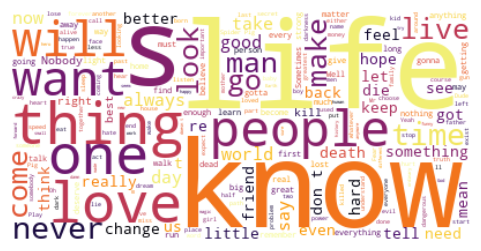

In [16]:
# Join all text from each row of the quote column into one string
text = " ".join(each for each in df.quote)

# Generate the wordcloud image
wordcloud = WordCloud(background_color="white",
                      colormap='inferno').generate(text)

# Use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud,                 # imshow, as when adding pictures to matplotlib axes
          interpolation='bilinear')  # smooths the image
ax.axis("off")
plt.show()

## Venn diagrams

Using the `matplotlib_venn` extension.

In [17]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

# Define our sets
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

### Basic venn diagram (default shows counts)

/Users/nicosarian/Desktop/DSI/Visualization/visualization-env/lib/python3.11/site-packages/matplotlib_venn/_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



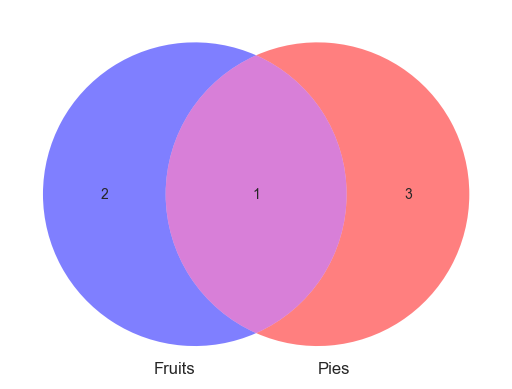

In [18]:
diagram = venn2_unweighted([A, B],
                          set_labels=('Fruits', 'Pies'),
                          set_colors=("blue", "red"),
                          alpha=0.5)
plt.show()

### Modify the venn diagram to show the actual items

The label IDs (`"10"`, `"11"`, `"01"`) come from the documentation:
`"10"` = only in A, `"11"` = in both A and B, `"01"` = only in B.

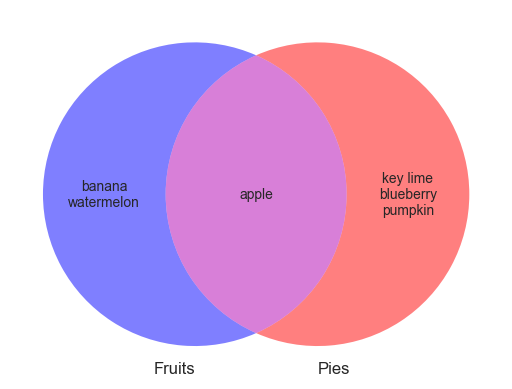

In [19]:
diagram = venn2_unweighted([A, B],
                          set_labels=('Fruits', 'Pies'),
                          set_colors=("blue", "red"),
                          alpha=0.5)

diagram.get_label_by_id("10").set_text("\n".join(A - B))   # only in A
diagram.get_label_by_id("11").set_text("\n".join(A & B))   # in both
diagram.get_label_by_id("01").set_text("\n".join(B - A))   # only in B

plt.show()

---
### Seaborn resources
- DataCamp seaborn cheatsheet: https://images.datacamp.com/image/upload/v1676302629/Marketing/Blog/Seaborn_Cheat_Sheet.pdf
- Seaborn example gallery: http://seaborn.pydata.org/examples/index.html